In [ ]:
import seaborn as sns
from inspect import _void
from turtle import mode
import numpy as np
import cv2
import time
import os
from cContoursAnalyze import ContoursAnalyze, AuxiliaryMeans
from sklearn.svm import SVC # "Support vector classifier"
import matplotlib.pyplot as plt
%matplotlib inline
sns.set()

In [50]:
test_dir = 'E:\\temp\\gj\\back_light\\2\\'
test_dir = 'E:\\temp\\gj\\back_light\\3\\'


files_name = os.listdir(test_dir)
imgs_name = [] #只取.bmp文件
for name in files_name:
    if name.split('.')[-1] == 'bmp':
        imgs_name.append(name)


#初始化参数
threshold1 = 50 #canny边缘检测阈值
threshold2 = 200
b1 = 120 #二值化阈值
index_tune= 1 #轮廓的初始索引
index_img = 0 #图片的初始索引

analyzer = ContoursAnalyze()
tools = AuxiliaryMeans()

#设置模板
imgtep = cv2.imread(os.path.join(test_dir, "10_true.bmp"), 1)
analyzer.initTemplate(imgtep)

ratio_num = 7
train_file_list = imgs_name[0: ratio_num]
test_file_list = imgs_name[ratio_num:]

In [51]:
def get_features(file_list):
    X = []; y=[]
    for imgName in file_list:
        imgpath = os.path.join(test_dir, imgName)
        img = cv2.imread(imgpath, 1)
        contoursFeatures = analyzer.fg(img, threshold1, threshold2, b1, index_tune)
        contours, idx, poly, hull, minRect = contoursFeatures["contours"], contoursFeatures["contourIndex"]\
        ,contoursFeatures["poly"],contoursFeatures["hull"],contoursFeatures["minRect"]
        
        arc = cv2.arcLength(contours[idx], True) #轮廓周长
        minCircle = cv2.minEnclosingCircle(poly) #最小包围圆（（x,y), radius)
        comScore =  analyzer.contoursCompare(contoursFeatures) #不旋转轮廓，直接比对，返回float类型分数

        feature = [arc, comScore, minCircle[0][0], minCircle[0][1], minCircle[1], 
                minRect[0][0],minRect[0][1], minRect[1][0], minRect[1][1], minRect[2]]

        X.append(feature)
        
        tag = imgName.split('.')[0]
        tag = tag.split('_')[-1]
        if tag == 'false':
            y.append(0)
        else:
            y.append(1)
            
    return np.array(X), np.array(y)

In [52]:
X_full, y_label_full = get_features(train_file_list+test_file_list) #无监督学习，用全部数据
print(train_file_list+test_file_list)

['10_true.bmp', '11_false.bmp', '1_false.bmp', '2_true.bmp', '3_false.bmp', '4_false.bmp', '5_false.bmp', '6_true.bmp', '7_true.bmp', '8_true.bmp', '9_true.bmp']


In [53]:
#无监督学习
#k-means聚类
from sklearn.cluster import KMeans
kmeans = KMeans(2, random_state=0)
kmeans.fit(X_full)
print(y_label_full); print(kmeans.predict(X_full))

[1 0 0 1 0 0 0 1 1 1 1]
[1 1 0 0 1 1 1 0 1 0 1]


In [54]:
from sklearn.decomposition import PCA  # 1. Choose the model class
pca1 = PCA(n_components=3)            # 2. Instantiate the model with hyperparameters
pca1.fit(X_full)                      # 3. Fit to data. Notice y is not specified!
X_2D = pca1.transform(X_full)         # 4. Transform the data to two dimensions

In [ ]:
x = X_2D[:, 0]
y = X_2D[:, 1]
z = X_2D[:, 2]

In [ ]:
import pandas as pd
irism = pd.DataFrame({'PCA1':x, 'PCA2':y, 'PCA3':z,'species':y_label_full})
print(irism)

In [ ]:
print(pca1.components_)
print(pca1.explained_variance_)

In [ ]:
# sns.lmplot("PCA1","PCA2", "PCA3", hue='species', data=irism, fit_reg=False)
coList = ['r', 'g']
colm = [coList[item] for item in y_label_full]
fig = plt.figure(figsize=(15,15))
ax1 = fig.add_subplot(111, projection='3d')
ax1.scatter(x,y,z, c=colm,marker = 'o', alpha=1, s=80)
ax1.legend()
ax1.set_xlabel('PCA1')
ax1.set_ylabel('PCA2')
ax1.set_zlabel('PCA3')
plt.show()

In [55]:
pca1 = PCA(n_components=2)            # 2. Instantiate the model with hyperparameters
pca1.fit(X_full)                      # 3. Fit to data. Notice y is not specified!
X_2D = pca1.transform(X_full)         # 4. Transform the data to two dimensions

In [56]:
x = X_2D[:, 0]
y = X_2D[:, 1]

import pandas as pd
irism = pd.DataFrame({'PCA1':x, 'PCA2':y,'species':y_label_full})
print(irism)

          PCA1        PCA2  species
0  -227.194653  -52.287987        1
1  -239.219982   11.355499        0
2   418.041650  -82.809453        0
3   423.661042 -113.486735        1
4  -255.340845  208.304795        0
5  -198.636614   -3.612209        0
6  -231.210055 -121.646600        0
7   367.496244  229.557289        1
8  -259.843573   -4.526247        1
9   434.345001   -6.154201        1
10 -232.098216  -64.694152        1


D:\Anaconda\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


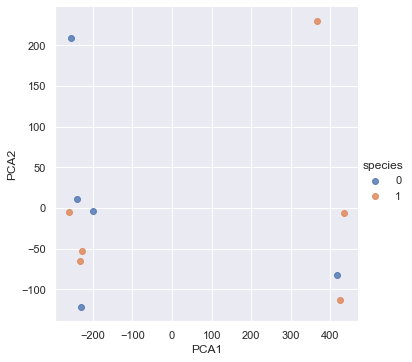

In [57]:
sns.lmplot("PCA1","PCA2", hue='species', data=irism, fit_reg=False)

In [58]:
#高斯混合模型
from sklearn.mixture import GaussianMixture      # 1. Choose the model class
model_gmm = GaussianMixture(n_components=2,
            covariance_type='full')  # 2. Instantiate the model with hyperparameters
model_gmm.fit(X_full)                    # 3. Fit to data. Notice y is not specified!
y_gmm = model_gmm.predict(X_full)        # 4. Determine cluster labels
print(y_gmm)
print(y_label_full)

[1 1 0 0 1 1 1 0 1 0 1]
[1 0 0 1 0 0 0 1 1 1 1]


In [59]:
#有监督学习的拟合
ratio_num = 7
Xtrain, Xtest = X_full[0:ratio_num], X_full[ratio_num:]
ytrain,ytest = y_label_full[0:ratio_num], y_label_full[ratio_num:]
from sklearn.naive_bayes import GaussianNB #朴素高斯贝叶斯
model_gnb = GaussianNB()
model_gnb.fit(Xtrain, ytrain)
y_train_pre = model_gnb.predict(Xtrain)

print(ytrain); print(y_train_pre)
y_test_pre = model_gnb.predict(Xtest)
print(ytest); print(y_test_pre)

[1 0 0 1 0 0 0]
[1 0 0 1 0 0 0]
[1 1 1 1]
[0 0 0 0]


In [61]:
#支持向量机
model_svc = SVC(kernel='rbf', C=1E6)
model_svc.fit(Xtrain, ytrain)

print(ytrain);print(model_svc.predict(Xtrain))
print(ytest); print(model_svc.predict(Xtest))

[1 0 0 1 0 0 0]
[1 0 0 1 0 0 0]
[1 1 1 1]
[1 1 1 0]


In [ ]:
from sklearn.svm import SVR
svm_poly = SVR(kernel="poly", degree=20, C=10, epsilon=0.)
svm_poly.fit(Xtrain, ytrain)
print(ytrain);print((svm_poly.predict(Xtrain)>=0.5).astype(np.int32))
print(ytest); print((svm_poly.predict(Xtest)>=0.5).astype(np.int32))

In [ ]:
#决策树与随机森林
#1、决策树
from sklearn.tree import DecisionTreeClassifier
dctree = DecisionTreeClassifier()
dctree.fit(Xtrain, ytrain)
print(ytrain); print(dctree.predict(Xtrain))
print(ytest); print(dctree.predict(Xtest))

In [ ]:
#2、随机森林
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
tree2 = DecisionTreeClassifier()
rfc = RandomForestClassifier(n_estimators=100, random_state=0)
rfc.fit(Xtrain, ytrain)
print(ytrain); print(rfc.predict(Xtrain))
print(ytest); print(rfc.predict(Xtest))